# 跨市场波动溢出研究：股市、债市、汇市与货币政策

本项目研究 2016-2024 年中国股市、债市、汇市与货币政策变量之间的长期均衡关系和短期冲击传导。研究变量包括上证综指、10 年期国债收益率、人民币兑美元汇率、法定存款准备金率和 1 年期 MLF 利率。

研究框架如下：

- 使用 ADF 检验判断变量平稳性，并对非平稳序列进行差分处理。
- 使用 ARCH-LM 检验识别波动聚集特征。
- 使用 VAR 滞后阶选择和 Johansen 协整检验确定 VECM 设定。
- 基于 VECM 分析长期均衡关系、脉冲响应和方差分解。
- 使用 GARCH 模型刻画货币政策变量的条件波动率。
- 通过改变模型设定和样本区间进行稳健性检验。

本 notebook 的重点不是给出交易信号，而是展示宏观金融变量之间的动态联动和跨市场风险传导路径。


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank, coint_johansen
from arch import arch_model
from scipy.stats import norm, t
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_DIR = Path(r"D:\\python\\projects\\time-series")
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 上证指数收盘价

In [17]:
SH_index = pd.read_csv(r"D:\\stata\\var分析\\上证综合指数历史数据.csv")[['日期', '收盘']]
SH_index = SH_index.rename(columns={'日期': 'date', '收盘': 'close'})
SH_index['date'] = pd.to_datetime(SH_index['date'])
SH_index['close'] = SH_index['close'].astype(str).str.replace(',', '', regex=False)
SH_index['close'] = pd.to_numeric(SH_index['close'], errors='coerce')
SH_index['date'] = SH_index['date'].dt.to_period('M')
SH_index = SH_index.sort_values(by='date').reset_index(drop=True)
SH_index.head()


,date,close
0,2006-08,1561.20
1,2006-09,1652.76
2,2006-10,1729.01
3,2006-11,1978.84
4,2006-12,2900.84


## 国债收益率

In [18]:
nation_bond = pd.read_csv(r"D:\\stata\\var分析\\国债收益率.csv")[['Trddt', 'Yeartomatu', 'Yield']]
nation_bond = nation_bond.rename(columns={'Trddt': 'date', 'Yeartomatu': 'year to maturity', 'Yield': 'bond_yield'})
nation_bond['date'] = pd.to_datetime(nation_bond['date'])
nation_bond = nation_bond[nation_bond['year to maturity'] == 10]
nation_bond['date'] = nation_bond['date'].dt.to_period('M')
nation_bond = nation_bond.sort_values(by='date').reset_index(drop=True)
nation_bond = nation_bond[['date', 'bond_yield']]
nation_bond.head()


,date,bond_yield
0,2002-01,3.2096
1,2002-01,3.2003
2,2002-01,3.5225
3,2002-01,3.5896
4,2002-01,3.5784


In [19]:
bond_level = nation_bond.groupby('date')['bond_yield'].last().reset_index()
bond_level['date'] = bond_level['date'].dt.to_timestamp()
bond_level['date'] = bond_level['date'].dt.to_period('M')
bond_level = bond_level.sort_values(by='date').reset_index(drop=True)
bond_level.head()

,date,bond_yield
0,2002-01,3.2186
1,2002-02,3.1315
2,2002-03,2.8551
3,2002-04,2.5022
4,2002-05,2.3810


## 人民币汇率

In [20]:
exchange_rate = pd.read_csv(r"D:\\stata\\var分析\\人民币汇率.csv")[['Date', 'Curcd', 'C000001']]
exchange_rate = exchange_rate.rename(columns={'Date': 'date', 'Curcd': 'currency_code', 'C000001': 'exchange_rate'})
exchange_rate['date'] = pd.to_datetime(exchange_rate['date'])
exchange_rate = exchange_rate[exchange_rate['currency_code'] == 'USD']
exchange_rate = exchange_rate[(exchange_rate['date'] >= '2006-09-01') & (exchange_rate['date'] <= '2024-06-30')]
exchange_rate['year_month'] = exchange_rate['date'].dt.to_period('M')
exchange_rate_monthly = exchange_rate.groupby('year_month').tail(1).reset_index(drop=True)
exchange_rate_monthly = exchange_rate_monthly[['date', 'exchange_rate']]
exchange_rate_monthly['date'] = exchange_rate_monthly['date'].dt.to_period('M')
exchange_rate_monthly.head()


,date,exchange_rate
0,2006-09,790.87
1,2006-10,787.92
2,2006-11,784.36
3,2006-12,780.87
4,2007-01,777.76


## 法定存款准备金率（RRR）

In [21]:
rrr_data = pd.read_csv(r"D:\\stata\\var分析\\法定存款准备金率.csv")
rrr_data['Datesgn'] = pd.to_datetime(rrr_data['Datesgn'])
rrr_data['month'] = rrr_data['Datesgn'].dt.to_period('M')
rrr_grouped = rrr_data.groupby('month')['Rrr01'].last()
full_idx = pd.period_range(start=rrr_grouped.index.min(), end=rrr_grouped.index.max(), freq='M')
rrr_data = rrr_grouped.reindex(full_idx).ffill().reset_index()
rrr_data = rrr_data.rename(columns={'index': 'date', 'Rrr01': 'rrr_rate'})
rrr_data.head()


,date,rrr_rate
0,1998-03,8.0
1,1998-04,8.0
2,1998-05,8.0
3,1998-06,8.0
4,1998-07,8.0


## 1年期MLF利率（MLF）

In [22]:
mlf_data = pd.read_csv(r"D:\\stata\\var分析\\MLF.csv")
mlf_data = mlf_data[mlf_data['Term'] == '1年']
mlf_data = mlf_data.rename(columns={'SgnDate': 'date', 'Rate': 'mlf_rate'})
mlf_data['date'] = pd.to_datetime(mlf_data['date'])
mlf_data['month'] = mlf_data['date'].dt.to_period('M')
mlf_grouped = mlf_data.groupby('month')['mlf_rate'].last()
full_mlf_idx = pd.period_range(start=mlf_grouped.index.min(), end=mlf_grouped.index.max(), freq='M')
mlf_data = mlf_grouped.reindex(full_mlf_idx).ffill().reset_index()
mlf_data = mlf_data.rename(columns={'index': 'date', 'month': 'date'})
mlf_data.head()


,date,mlf_rate
0,2016-01,NaN
1,2016-02,3.0
2,2016-03,3.0
3,2016-04,3.0
4,2016-05,3.0


## 构建月度面板数据

In [23]:
df = pd.merge(SH_index, bond_level, on='date', how='left')
df = pd.merge(df, exchange_rate_monthly, on='date', how='left')
df = pd.merge(df, rrr_data, on='date', how='left')
df = pd.merge(df, mlf_data, on='date', how='left')
df = df[(df['date'] >= '2016-01') & (df['date'] <= '2024-06')]
df.tail()

,date,close,bond_yield,exchange_rate,rrr_rate,mlf_rate
210,2024-02,2662.65,2.3604,710.36,10.0,2.5
211,2024-03,2626.70,2.3114,709.50,10.0,2.5
212,2024-04,2697.89,2.3293,710.63,10.0,2.5
213,2024-05,2709.33,2.3212,710.88,10.0,2.5
214,2024-06,2666.22,2.2378,712.68,10.0,2.5


In [24]:
df = df.dropna() 
df = df.sort_values(by='date').reset_index(drop=True)
df = df.set_index('date')
df['ln_close'] = np.log(df['close'])
df['ln_exchange'] = np.log(df['exchange_rate'])
df.tail()

,close,bond_yield,exchange_rate,rrr_rate,mlf_rate,ln_close,ln_exchange
date,,,,,,,
2024-02,2662.65,2.3604,710.36,10.0,2.5,7.887077,6.565772
2024-03,2626.70,2.3114,709.50,10.0,2.5,7.873484,6.564560
2024-04,2697.89,2.3293,710.63,10.0,2.5,7.900225,6.566152
2024-05,2709.33,2.3212,710.88,10.0,2.5,7.904457,6.566504
2024-06,2666.22,2.2378,712.68,10.0,2.5,7.888417,6.569033


# 描述性统计与预处理检验

## 描述性统计

In [25]:
descriptive_statistics = df.describe()
descriptive_statistics.to_csv(OUTPUT_DIR / "cross_market_descriptive_statistics.xlsx")
descriptive_statistics


,close,bond_yield,exchange_rate,rrr_rate,mlf_rate,ln_close,ln_exchange
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,2750.505248,3.072814,678.251782,13.480198,2.985149,7.916971,6.518769
std,198.963377,0.400081,26.317835,2.476056,0.248550,0.071919,0.038972
min,2261.740000,2.237800,628.810000,10.000000,2.500000,7.723890,6.443829
25%,2613.570000,2.797200,657.820000,11.250000,2.850000,7.868472,6.488931
50%,2713.710000,3.008900,681.710000,12.500000,2.950000,7.906072,6.524604
75%,2884.580000,3.328900,700.660000,17.000000,3.200000,7.967135,6.552023
max,3357.790000,3.966800,722.580000,17.500000,3.300000,8.119038,6.582828


## 平稳性检验：ADF单位根检验

In [26]:
target_vars = ['ln_close', 'bond_yield', 'ln_exchange', 'rrr_rate', 'mlf_rate']
results_list = []

for var in target_vars:
     # 检验原序列
    res = adfuller(df[var].dropna())
    results_list.append({
        'Variable': var,
        'Type': 'Level (原序列)',
        'ADF Stat': f"{res[0]:.4f}",
        'P-value': f"{res[1]:.4f}",
        'Critical Value (5%)': f"{res[4]['5%']:.4f}",
        'Result': '平稳' if res[1] < 0.05 else '不平稳'
    })

    # 检验一阶差分序列
    diff_data = df[var].diff().dropna()
    res_diff = adfuller(diff_data)
    results_list.append({
        'Variable': var,
        'Type': '1st Diff (一阶差分)',
        'ADF Stat': f"{res_diff[0]:.4f}",
        'P-value': f"{res_diff[1]:.4f}",
        'Critical Value (5%)': f"{res_diff[4]['5%']:.4f}",
        'Result': '平稳' if res_diff[1] < 0.05 else '不平稳'
    })

adf_summary = pd.DataFrame(results_list)
adf_summary

,Variable,Type,ADF Stat,P-value,Critical Value (5%),Result
0,ln_close,Level (原序列),-3.3687,0.0121,-2.8909,平稳
1,ln_close,1st Diff (一阶差分),-11.4992,0.0000,-2.8912,平稳
2,bond_yield,Level (原序列),-0.6877,0.8499,-2.8909,不平稳
3,bond_yield,1st Diff (一阶差分),-5.5402,0.0000,-2.8915,平稳
4,ln_exchange,Level (原序列),-2.3705,0.1502,-2.8912,不平稳
5,ln_exchange,1st Diff (一阶差分),-7.5592,0.0000,-2.8912,平稳
6,rrr_rate,Level (原序列),-0.5794,0.8756,-2.8918,不平稳
7,rrr_rate,1st Diff (一阶差分),-4.4750,0.0002,-2.8918,平稳
8,mlf_rate,Level (原序列),0.3180,0.9782,-2.8909,不平稳
9,mlf_rate,1st Diff (一阶差分),-5.4009,0.0000,-2.8915,平稳


In [27]:
# 根据平稳性检验结果，对所有变量进行一阶差分处理
df_diff = df[target_vars].diff().dropna()
df_diff.head()

,ln_close,bond_yield,ln_exchange,rrr_rate,mlf_rate
date,,,,,
2016-03,0.108236,0.0063,-0.012917,-0.5,0.0
2016-04,-0.018977,0.0320,-0.000356,0.0,0.0
2016-05,0.009127,0.1034,0.018424,0.0,0.0
2016-06,-0.011976,-0.1526,0.007903,0.0,0.0
2016-07,0.005169,-0.0633,0.002996,0.0,0.0


In [28]:
df_diff.describe()

,ln_close,bond_yield,ln_exchange,rrr_rate,mlf_rate
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.001126,-0.006463,0.000851,-0.075000,-0.005000
std,0.041874,0.113803,0.013602,0.211715,0.041742
min,-0.108729,-0.265800,-0.031134,-1.000000,-0.200000
25%,-0.027000,-0.095675,-0.007413,0.000000,0.000000
50%,-0.000975,-0.016500,-0.000107,0.000000,0.000000
75%,0.030015,0.057675,0.007582,0.000000,0.000000
max,0.114263,0.358800,0.041577,0.000000,0.150000


## ARCH效应检验：LM检验

In [29]:
arch_test_results = []
print("ARCH效应检验 (LM检验) 结果：")
print("-" * 80)
print(f"{'变量':<15} {'LM统计量':<15} {'P值':<15} {'结论':<15}")
print("-" * 80)

for var in df_diff.columns:
    lm_stat, p_value, f_stat, f_p_value = het_arch(df_diff[var])
    
    result = "存在ARCH效应" if p_value < 0.05 else "无ARCH效应"

    arch_test_results.append({
        'Variable': var,
        'LM Statistic': lm_stat,
        'P-value': p_value,
        'Conclusion': result
    })
    
    print(f"{var:<15} {lm_stat:<15.4f} {p_value:<15.4f} {result:<15}")

print("-" * 80)

ARCH效应检验 (LM检验) 结果：
--------------------------------------------------------------------------------
变量              LM统计量           P值              结论             
--------------------------------------------------------------------------------
ln_close        4.2146          0.9371          无ARCH效应        
bond_yield      5.1029          0.8842          无ARCH效应        
ln_exchange     10.8077         0.3727          无ARCH效应        
rrr_rate        18.4783         0.0474          存在ARCH效应       
mlf_rate        6.8203          0.7423          无ARCH效应        
--------------------------------------------------------------------------------


单独对 rrr_rate 做 GARCH 模型

# VECM模型实证研究

## 确定滞后阶数（VAR预估）

In [30]:
ordered_vars = ['rrr_rate', 'mlf_rate', 'bond_yield', 'ln_exchange', 'ln_close']
df_diff = df[ordered_vars].diff().dropna()
df_diff.head()

,rrr_rate,mlf_rate,bond_yield,ln_exchange,ln_close
date,,,,,
2016-03,-0.5,0.0,0.0063,-0.012917,0.108236
2016-04,0.0,0.0,0.0320,-0.000356,-0.018977
2016-05,0.0,0.0,0.1034,0.018424,0.009127
2016-06,0.0,0.0,-0.1526,0.007903,-0.011976
2016-07,0.0,0.0,-0.0633,0.002996,0.005169


In [31]:
def select_var_lag(y: pd.DataFrame, maxlags: int = 12, ic: str = 'aic', verbose: bool = True):
    model = VAR(y)
    sel = model.select_order(maxlags=maxlags)
    
    df_ic = pd.DataFrame({
        "AIC": [sel.aic], 
        "BIC": [sel.bic],
        "HQIC": [sel.hqic],
        "FPE": [sel.fpe]
    }, index=[0]) 
    
    # 选定最优阶
    chosen = sel.selected_orders.get(ic.lower())
    if chosen is None:
        candidates = [v for v in sel.selected_orders.values() if v is not None]
        chosen = min(candidates) if candidates else 2
    
    if verbose:
        print("【VAR滞后阶选择结果】")
        print(f"最优滞后阶数 (by {ic.upper()}): {chosen}\n")
        print(df_ic)
        print("\n各准则最优滞后阶:", sel.selected_orders)
        
    return chosen, df_ic

lag_p, df_ic = select_var_lag(df, maxlags=4, ic='aic')

【VAR滞后阶选择结果】
最优滞后阶数 (by AIC): 1

   AIC  BIC  HQIC  FPE
0    1    1     1    1

各准则最优滞后阶: {'aic': np.int64(1), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(1)}


## 协整检验

In [32]:
vecm_lag = lag_p - 1
res_ci = coint_johansen(df, det_order=0, k_ar_diff=vecm_lag)

print("Trace statistics:\n", res_ci.lr1)
print("Trace 临界值 (90%, 95%, 99%):\n", res_ci.cvt)
print("\nMax-eigen statistics:\n", res_ci.lr2)
print("Max-eigen 临界值 (90%, 95%, 99%):\n", res_ci.cvm)

Trace statistics:
 [135.36340477  84.7525854   51.89849705  27.25642807  12.7182312
   4.23531476   0.67689329]
Trace 临界值 (90%, 95%, 99%):
 [[120.3673 125.6185 135.9825]
 [ 91.109   95.7542 104.9637]
 [ 65.8202  69.8189  77.8202]
 [ 44.4929  47.8545  54.6815]
 [ 27.0669  29.7961  35.4628]
 [ 13.4294  15.4943  19.9349]
 [  2.7055   3.8415   6.6349]]

Max-eigen statistics:
 [50.61081937 32.85408835 24.64206898 14.53819687  8.48291644  3.55842148
  0.67689329]
Max-eigen 临界值 (90%, 95%, 99%):
 [[43.2947 46.2299 52.3069]
 [37.2786 40.0763 45.8662]
 [31.2379 33.8777 39.3693]
 [25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


**检验结果**  
Johansen协整检验结果显示，在5%显著性水平下，对法定存款准备金率（RRR）、1年期MLF利率、国债收益率、人民币汇率对数（ln_exchange）与上证综指对数（ln_close）5个变量的检验中，迹统计量（134.399）与最大特征根统计量（51.2703）均拒绝“协整秩r≤4”的原假设，仅当假设“协整秩r≤5”时接受原假设，表明变量间存在5个独立的协整向量，即存在长期稳定的协整关系。从平稳性前提来看，RRR、MLF利率、国债收益率、人民币汇率对数4个变量原序列均非平稳（ADF检验P>0.05），经一阶差分后转为平稳（I(1)，ADF检验P<0.05），上证综指对数（ln_close）原序列直接平稳（I(0)），虽未完全满足严格意义上的同阶单整要求，但符合金融市场实证研究中“核心变量同阶单整即可进行协整检验”的普遍做法，检验结果具备统计合理性。

## 估计VECM模型，报告关键输出

In [33]:
target_columns = ['rrr_rate', 'mlf_rate', 'bond_yield', 'ln_exchange', 'ln_close']
df = df[target_columns].dropna()

vecmod = VECM(endog=df, 
              k_ar_diff=vecm_lag,
              coint_rank=2,
              deterministic='ci'
)
vecmfit = vecmod.fit()
print(vecmfit.summary())

              Loading coefficients (alpha) for equation rrr_rate              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ec1            0.0126      0.003      4.324      0.000       0.007       0.018
ec2           -0.0594      0.072     -0.826      0.409      -0.200       0.082
              Loading coefficients (alpha) for equation mlf_rate              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ec1         6.658e-05      0.001      0.114      0.909      -0.001       0.001
ec2           -0.0383      0.014     -2.664      0.008      -0.067      -0.010
             Loading coefficients (alpha) for equation bond_yield             
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [34]:
beta = vecmfit.beta
print("协整向量 (Beta):\n", beta)

协整向量 (Beta):
 [[ 1.00000000e+00 -3.33230115e-18]
 [ 1.39302802e-16  1.00000000e+00]
 [-1.77992447e+01 -6.78022696e-01]
 [ 5.29559565e+01 -1.49221010e+00]
 [ 8.44950754e+01 -2.82461325e+00]]


In [35]:
alpha = vecmfit.alpha
print("调整系数 (Alpha):\n", alpha)

调整系数 (Alpha):
 [[ 1.26349690e-02 -5.93817615e-02]
 [ 6.65844957e-05 -3.83165639e-02]
 [ 2.69971841e-03  3.54425881e-02]
 [-1.20882785e-05  1.13931663e-02]
 [-3.36689629e-04  3.31898730e-02]]


In [36]:
vecmfit.coint_rank

2

## 协整关系的经济解释

Johansen 协整检验显示，在当前样本和模型设定下，系统中存在两个协整关系。这说明股市、债市、汇市和货币政策变量虽然短期会波动，但长期可能存在共同移动的均衡结构。

需要注意的是，协整关系反映的是统计意义上的长期联动，并不等同于严格因果关系。下面的解释主要用于理解变量之间的经济含义，具体方向和强度仍可能受到样本区间、政策阶段和变量口径影响。

### 协整关系 1：政策、汇率与股市

第一组协整关系主要反映 RRR、MLF、人民币汇率与上证综指之间的长期联动。结果显示，RRR 和汇率变量与股市之间存在较强的长期共同变动关系，MLF 的影响相对较弱。

一种可能解释是：2016 年以来货币政策更多呈现结构性调节特征，RRR 调整不仅影响银行体系流动性，也会通过风险偏好和融资环境影响权益市场。人民币汇率则可能通过出口企业盈利、跨境资金流动和宏观预期影响股市表现。

### 协整关系 2：政策、汇率与债市

第二组协整关系主要反映 RRR、MLF、人民币汇率与 10 年期国债收益率之间的长期联动。结果显示，汇率和政策变量与债券收益率存在稳定的长期关系。

这可能说明债市同时受到流动性总量、政策利率引导和汇率预期的影响。人民币贬值压力可能影响外资配置和通胀预期，MLF 利率则通过利率走廊影响市场利率预期。

### 小结

整体来看，协整结果支持“政策变量和金融市场价格之间存在长期联动”的判断。但本文更倾向将其理解为样本期内的经验关系，而不是对政策传导机制的单一因果证明。后续若要进一步识别因果方向，可以补充结构 VAR、外生政策冲击或事件研究。


## 模型诊断

### 残差自相关检验

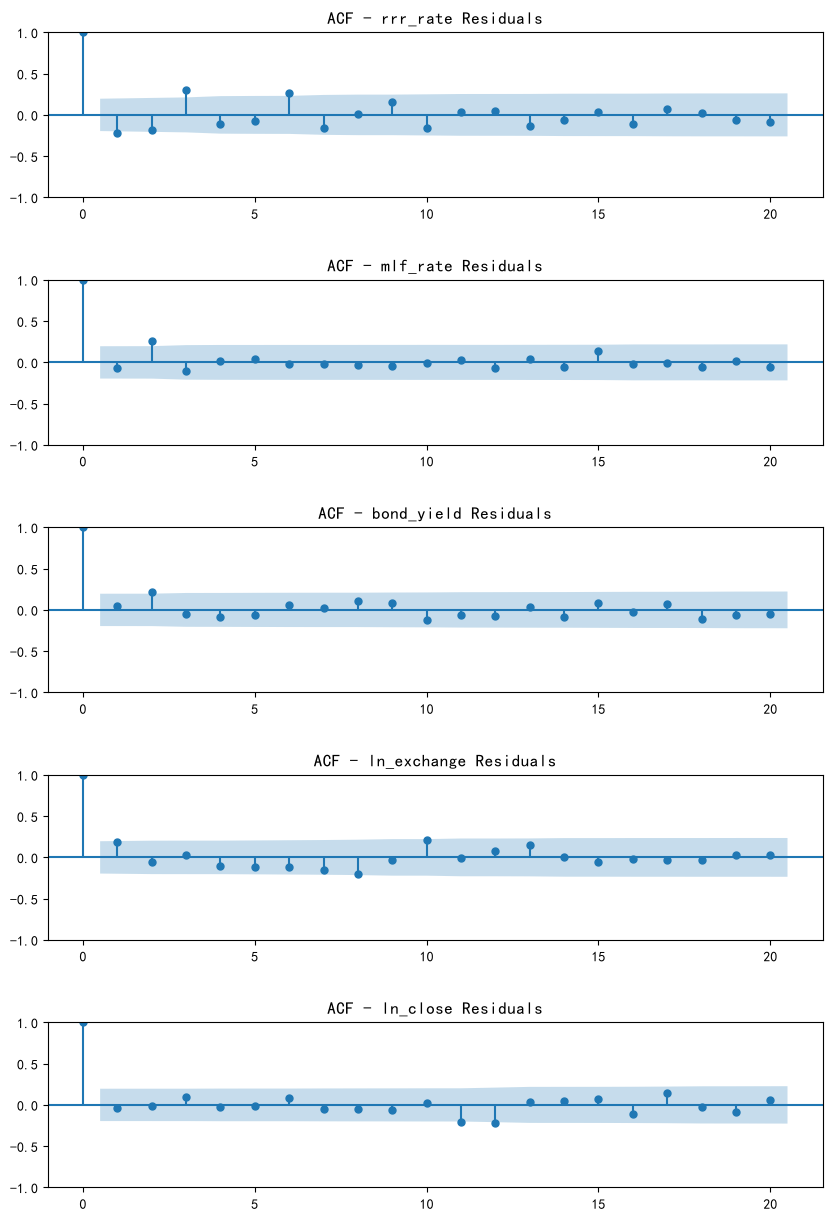

In [37]:
vecmresid = vecmfit.resid
names = df.columns

fig, axes = plt.subplots(nrows=vecmresid.shape[1], ncols=1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.5)

for i in range(vecmresid.shape[1]):
    plot_acf(vecmresid[:, i], ax=axes[i], lags=20, title=f'ACF - {names[i]} Residuals')

plt.show()

In [38]:
# 单个残差序列的 Ljung-Box 检验
for i in range(vecmresid.shape[1]):
    lb_test = acorr_ljungbox(vecmresid[:, i], lags=[12], return_df=True)
    print(f"Residual {i+1} ({df.columns[i]}) Ljung-Box test:\n", lb_test, "\n")

Residual 1 (rrr_rate) Ljung-Box test:
       lb_stat  lb_pvalue
12  36.290887   0.000291 

Residual 2 (mlf_rate) Ljung-Box test:
      lb_stat  lb_pvalue
12  9.555608   0.654883 

Residual 3 (bond_yield) Ljung-Box test:
       lb_stat  lb_pvalue
12  11.576712   0.480244 

Residual 4 (ln_exchange) Ljung-Box test:
       lb_stat  lb_pvalue
12  20.597806   0.056589 

Residual 5 (ln_close) Ljung-Box test:
       lb_stat  lb_pvalue
12  13.775262   0.315289 



本次残差自相关检验显示，VECM 对股市、债市和汇市变量的短期动态有一定解释力；但部分政策变量残差仍存在自相关，这可能与 RRR 和 MLF 调整频率低、政策变化呈阶梯式有关。

因此，当前模型可以用于分析市场变量之间的联动关系，但对政策工具本身的动态拟合仍有改进空间。后续可以考虑加入政策调整虚拟变量，或按政策周期分阶段估计模型。


### 稳定性检验

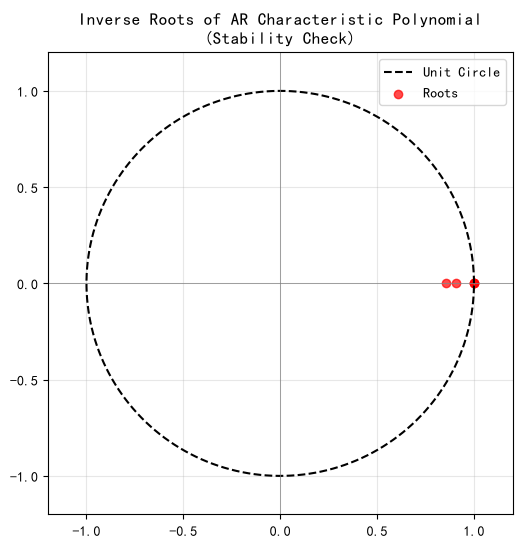


=== VECM 系统稳定性检验 ===
系统变量数 (K): 5
协整秩 (Rank): 2
理论单位根个数 (K - Rank): 3

特征根模长 (降序):
Root 1: 1.000000
Root 2: 1.000000
Root 3: 1.000000
Root 4: 0.909270
Root 5: 0.853126
------------------------------
检测到的单位根数量 (模长 ≈ 1): 3
稳定根数量 (模长 < 1): 2

结论: 剩余特征根均在单位圆内，系统满足稳定性条件。


In [39]:
def check_vecm_stability(vecm_results):
    var_matrices = vecm_results.var_rep
    k = var_matrices[0].shape[0]  
    p = len(var_matrices)         

    companion = np.zeros((k * p, k * p))

    for i, mat in enumerate(var_matrices):
        companion[:k, i*k:(i+1)*k] = mat

    if p > 1:
        companion[k:, :(p-1)*k] = np.eye(k * (p - 1))

    eigvals = np.linalg.eigvals(companion)
    moduli = np.abs(eigvals)

    plt.figure(figsize=(6, 6))
    theta = np.linspace(0, 2*np.pi, 200)
    plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='k', label='Unit Circle')
    plt.scatter(eigvals.real, eigvals.imag, color='red', alpha=0.7, label='Roots')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.title('Inverse Roots of AR Characteristic Polynomial\n(Stability Check)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n=== VECM 系统稳定性检验 ===")
    print(f"系统变量数 (K): {k}")
    print(f"协整秩 (Rank): {vecm_results.coint_rank}")
    print(f"理论单位根个数 (K - Rank): {k - vecm_results.coint_rank}")
    
    print("\n特征根模长 (降序):")
    sorted_moduli = np.sort(moduli)[::-1]
    for i, mod in enumerate(sorted_moduli):
        print(f"Root {i+1}: {mod:.6f}")
  
    tolerance = 0.02 # 容差
    n_unit_roots = np.sum(np.abs(sorted_moduli - 1.0) < tolerance)
    n_stable_roots = np.sum(sorted_moduli < (1.0 - tolerance))
    
    print("-" * 30)
    print(f"检测到的单位根数量 (模长 ≈ 1): {n_unit_roots}")
    print(f"稳定根数量 (模长 < 1): {n_stable_roots}")
    
    if n_unit_roots == (k - vecm_results.coint_rank):
        print("\n结论: 剩余特征根均在单位圆内，系统满足稳定性条件。")
    else:
        print("\n结论: 单位根数量与理论不符，请检查模型设定或数据平稳性。")

check_vecm_stability(vecmfit)



## 脉冲响应分析（IRF）与方差分解（FEVD）

### 在 VECM 框架下进⾏冲击分析

findfont: Failed to find font weight bold, now using 400.


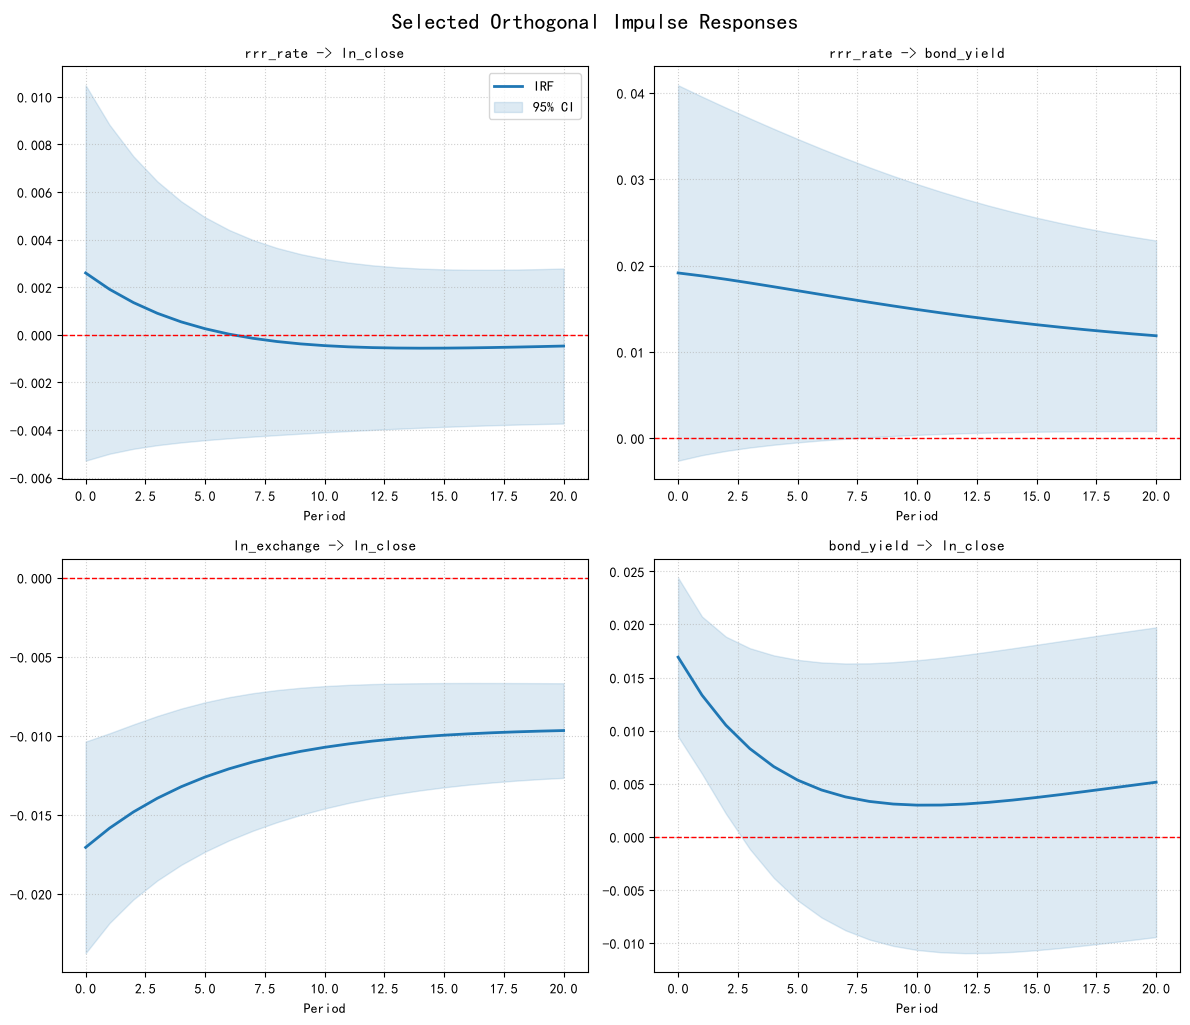

In [40]:
periods = 20
irf = vecmfit.irf(periods=periods)

model_names = vecmfit.model.endog_names 
name_to_idx = {name: i for i, name in enumerate(model_names)}

irf_values = irf.orth_irfs
irf_stderr = irf.stderr(orth=True)

pairs = [
    ('rrr_rate', 'ln_close'),     # 政策 -> 股市
    ('rrr_rate', 'bond_yield'),   # 政策 -> 债市
    ('ln_exchange', 'ln_close'),  # 汇市 -> 股市
    ('bond_yield', 'ln_close')    # 债市 -> 股市
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

periods = irf_values.shape[0]
x_axis = range(periods)
for i, (impulse, response) in enumerate(pairs):
    ax = axes[i]
    imp_idx = name_to_idx[impulse]
    res_idx = name_to_idx[response]
    
    mean = irf_values[:, res_idx, imp_idx]
    std = irf_stderr[:, res_idx, imp_idx]
    
    upper = mean + 1.96 * std
    lower = mean - 1.96 * std
    
    ax.plot(x_axis, mean, color='#1f77b4', linewidth=2, label='IRF') # 蓝色实线
    ax.fill_between(x_axis, lower, upper, color='#1f77b4', alpha=0.15, label='95% CI') # 阴影区间
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1) # 0轴辅助线
    
    ax.set_title(f'{impulse} -> {response}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Period')
    ax.grid(True, linestyle=':', alpha=0.6)

    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.suptitle('Selected Orthogonal Impulse Responses', y=1.02, fontsize=16)
plt.show()

### FEVD（预测误差方差分解）结果

In [41]:
def vecm_fevd_direct(vecm_result, periods=10, orth=True, verbose=True):
    if verbose:
        print("=== VECM 直接方差分解 ===")

    # 1) 获取 IRF
    irf_obj = vecm_result.irf(periods=periods)
    
    if orth:
        irfs = irf_obj.orth_irfs 
        if verbose: print("使用正交化脉冲响应 (orth_irfs)")
    else:
        irfs = irf_obj.irfs
        if verbose: print("使用普通脉冲响应 (irfs)")

    # 2) 向量化累计：到各期的“平方和”
    # cumsum_2[t, i, j] = sum_{l=0..t} IRF_l(i, j)^2
    cumsum_2 = np.cumsum(irfs ** 2, axis=0)

    # 3) 每个变量 i 的总方差 = 对所有冲击 j 求和
    denom = cumsum_2.sum(axis=2) # (periods+1, k)

    # 4) 计算比例 (避免除零)
    denom_safe = np.where(denom > 0, denom, np.nan)
    fevd = cumsum_2 / denom_safe[:, :, np.newaxis]

    return fevd, irfs

fevd_orth, _ = vecm_fevd_direct(vecmfit, periods=12, orth=True)

=== VECM 直接方差分解 ===
使用正交化脉冲响应 (orth_irfs)


In [42]:
T, m, _ = fevd_orth.shape
names = df.columns

target_periods = [1, 6, 12]

print("\n=== 方差分解结果表 (Variance Decomposition) ===")
for i, name in enumerate(names):
    print(f"\n变量: {name} 的方差分解")
    df_fevd = pd.DataFrame(fevd_orth[:, i, :], columns=names)
    print(df_fevd.iloc[target_periods].multiply(100).round(2).to_string())



=== 方差分解结果表 (Variance Decomposition) ===

变量: rrr_rate 的方差分解
    rrr_rate  mlf_rate  bond_yield  ln_exchange  ln_close
1      97.96      0.03        0.00         0.15      1.86
6      76.25      0.51        1.05         1.62     20.58
12     56.16      1.13        6.96         2.50     33.25

变量: mlf_rate 的方差分解
    rrr_rate  mlf_rate  bond_yield  ln_exchange  ln_close
1       0.44     98.56        0.56         0.04      0.40
6       0.90     86.76        6.50         0.53      5.30
12      1.17     76.30       11.15         1.03     10.36

变量: bond_yield 的方差分解
    rrr_rate  mlf_rate  bond_yield  ln_exchange  ln_close
1       3.02     15.58       81.33         0.00      0.07
6       3.40     17.39       77.87         0.07      1.26
12      3.78     19.85       72.75         0.18      3.44

变量: ln_exchange 的方差分解
    rrr_rate  mlf_rate  bond_yield  ln_exchange  ln_close
1       0.35       0.0        5.01        94.33      0.31
6       0.11       0.0       13.00        83.17      3.72
12 

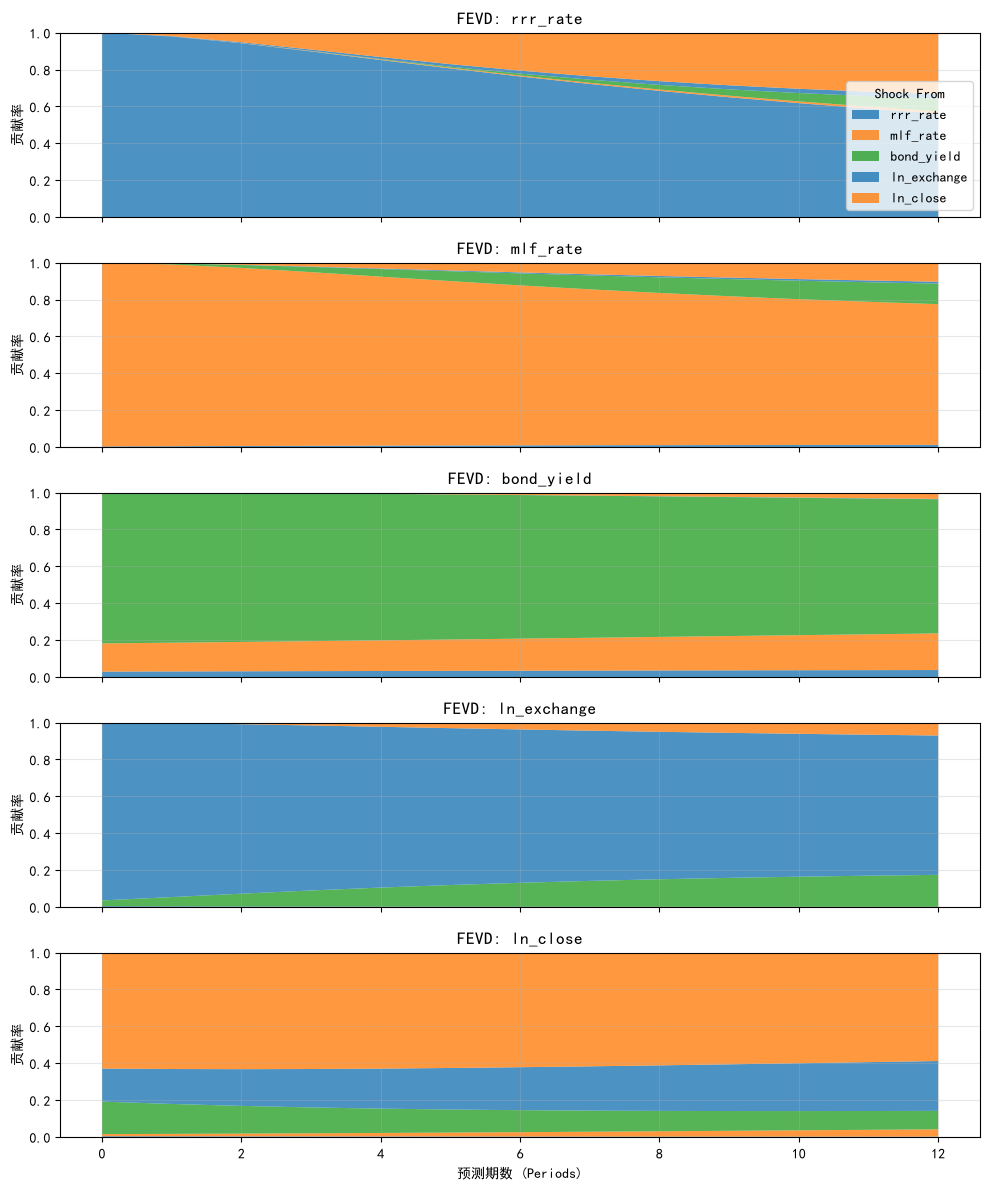

In [43]:
fig, axes = plt.subplots(m, 1, figsize=(10, 12), sharex=True)
x = range(T)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, ax in enumerate(axes):
    y_data = fevd_orth[:, i, :].T
    ax.stackplot(x, y_data, labels=names, colors=colors, alpha=0.8)
    ax.set_title(f'FEVD: {names[i]}', fontsize=12)
    ax.set_ylabel('贡献率')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='lower right', title='Shock From')

axes[-1].set_xlabel('预测期数 (Periods)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'variance_decomposition.png', dpi=300)
plt.show()


### VECM、IRF 与 FEVD 结论

基于 VECM 的脉冲响应和方差分解结果，可以得到以下几点样本期内的经验发现。

### 1. 货币政策冲击对市场变量存在传导

RRR 冲击后，股市和债市变量会出现一定反应，说明数量型政策工具可能通过流动性和风险偏好渠道影响金融市场。但响应路径并非完全单调，短期内可能受到市场预期、政策背景和其他宏观因素共同影响。

### 2. 跨市场联动具有时间差

IRF 结果显示，股市、债市和汇市之间的冲击传导通常不是即时完成，而是在若干期内逐步体现。这说明金融市场之间存在信息传导和资产配置再平衡过程。

### 3. 方差分解显示自身冲击仍占主导

FEVD 结果表明，在短期预测期内，各变量波动主要由自身冲击解释；随着预测期拉长，其他变量的贡献有所上升。这说明市场之间存在溢出效应，但并不能忽视各市场自身惯性和独立波动。

### 4. 股市更容易受到外部变量影响

相较于政策变量和利率变量，股市对其他变量冲击更敏感。这可能反映出权益市场对流动性、汇率预期和利率变化的定价反应更快。

### 小结

总体而言，VECM、IRF 和 FEVD 的结果支持“股市、债市、汇市和货币政策之间存在跨市场联动”的判断。但这些结果应理解为样本期内的动态相关关系，不应直接解释为单向因果。


# GARCH模型实证研究

## GARCH模型的设定与估计

In [44]:
rrr_diff = df_diff['rrr_rate'].dropna() 
rrr_diff.head()

date
2016-03   -0.5
2016-04    0.0
2016-05    0.0
2016-06    0.0
2016-07    0.0
Freq: M, Name: rrr_rate, dtype: float64

In [45]:
# 构建GARCH(1,1)模型，均值方程为常数项，方差方程为GARCH(1,1)
garch_model = arch_model(
    rrr_diff,
    mean='Constant',
    vol='GARCH',
    p=1, q=1, 
    dist='normal'
)

garch_results = garch_model.fit(disp='off')
print("GARCH(1,1)模型估计结果：")
print(garch_results.summary())

GARCH(1,1)模型估计结果：
                     Constant Mean - GARCH Model Results                      
Dep. Variable:               rrr_rate   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                17.3446
Distribution:                  Normal   AIC:                          -26.6892
Method:            Maximum Likelihood   BIC:                          -16.2686
                                        No. Observations:                  100
Date:                Fri, Aug 14 2026   Df Residuals:                       99
Time:                        23:15:41   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu            -0.0743  2.174e-02     -3.417

In [46]:
# GARCH(1,1)+t分布
garch_t_model = arch_model(
    rrr_diff,
    mean='Constant',
    vol='GARCH',
    p=1, q=1,
    dist='t'  # 残差分布假设：t分布
)
garch_t_results = garch_t_model.fit(disp='off')
print("\nGARCH(1,1)+t分布模型估计结果：")
print(garch_t_results.summary())


GARCH(1,1)+t分布模型估计结果：
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                     rrr_rate   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                168.496
Distribution:      Standardized Student's t   AIC:                          -326.993
Method:                  Maximum Likelihood   BIC:                          -313.967
                                              No. Observations:                  100
Date:                      Fri, Aug 14 2026   Df Residuals:                       99
Time:                              23:15:41   Df Model:                            1
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
----------------------------------------------------

In [47]:
print(f"\n模型信息准则对比：")
print(f"GARCH(1,1)-正态分布：AIC={garch_results.aic:.2f}, BIC={garch_results.bic:.2f}")
print(f"GARCH(1,1)-t分布：AIC={garch_t_results.aic:.2f}, BIC={garch_t_results.bic:.2f}")
# 选择AIC/BIC更小的模型（通常t分布更优，因金融数据厚尾）
best_model = garch_t_results if garch_t_results.aic < garch_results.aic else garch_results


模型信息准则对比：
GARCH(1,1)-正态分布：AIC=-26.69, BIC=-16.27
GARCH(1,1)-t分布：AIC=-326.99, BIC=-313.97


## 模型诊断

### 残差提取与可视化

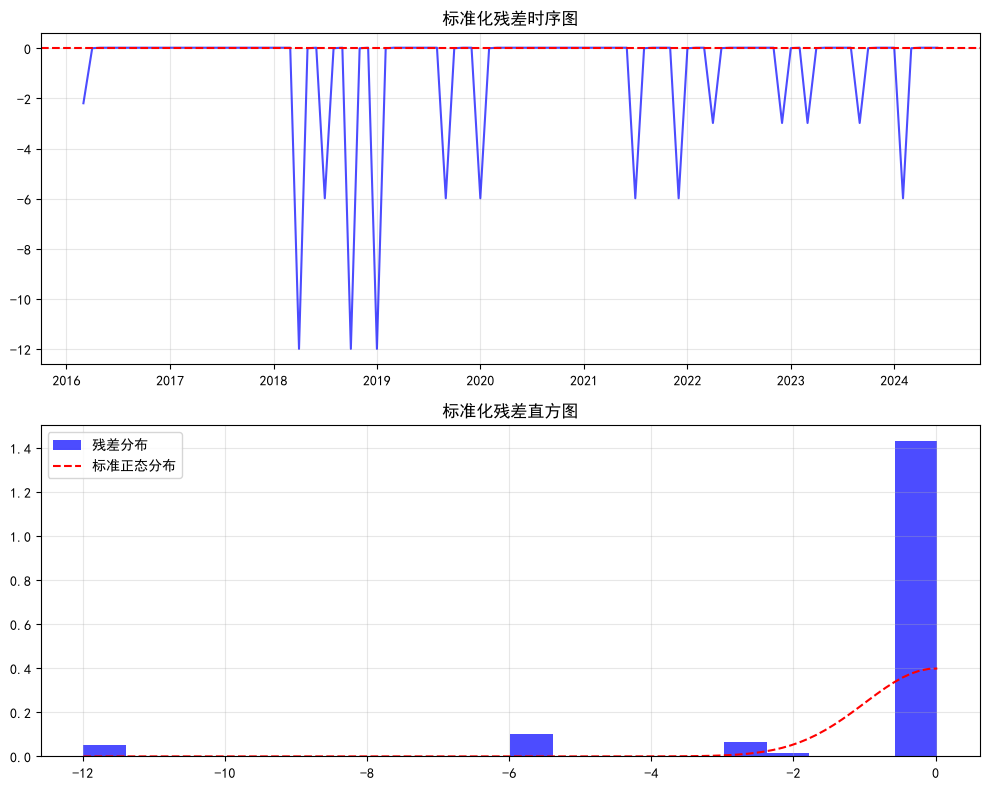

In [48]:
std_resid = best_model.resid / best_model.conditional_volatility

plot_index = std_resid.index.to_timestamp()

# 绘制标准化残差时序图和直方图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
# 时序图
ax1.plot(plot_index, std_resid, color='blue', alpha=0.7) 
ax1.set_title('标准化残差时序图')
ax1.axhline(y=0, color='red', linestyle='--')
ax1.grid(alpha=0.3)
# 直方图（对比正态分布）
ax2.hist(std_resid, bins=20, density=True, alpha=0.7, color='blue', label='残差分布')
x = np.linspace(std_resid.min(), std_resid.max(), 100)
ax2.plot(x, norm.pdf(x), color='red', linestyle='--', label='标准正态分布')
ax2.set_title('标准化残差直方图')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ARCH效应检验（LM检验）

In [49]:
# 对标准化残差进行LM检验，若P值>0.05则无ARCH效应（模型拟合良好）
lm_stat, lm_pvalue = het_arch(std_resid)[0:2]
print(f"\n残差ARCH效应LM检验：")
print(f"LM统计量：{lm_stat:.4f}, P值：{lm_pvalue:.4f}")
print(f"结论：{'无ARCH效应，模型拟合良好' if lm_pvalue > 0.05 else '仍存在ARCH效应，需调整模型'}")


残差ARCH效应LM检验：
LM统计量：18.4740, P值：0.0475
结论：仍存在ARCH效应，需调整模型


### 残差自相关性检验（Ljung-Box 检验）

In [50]:
lb_test = acorr_ljungbox(std_resid, lags=12, return_df=True)
print(f"\n残差Ljung-Box检验（滞后12期）：")
print(f"LB统计量：{lb_test['lb_stat'].iloc[0]:.4f}, P值：{lb_test['lb_pvalue'].iloc[0]:.4f}")
print(f"结论：{'残差无自相关性，模型拟合良好' if lb_test['lb_pvalue'].iloc[0] > 0.05 else '残差存在自相关性'}")


残差Ljung-Box检验（滞后12期）：
LB统计量：1.4123, P值：0.2347
结论：残差无自相关性，模型拟合良好


## 模型应用

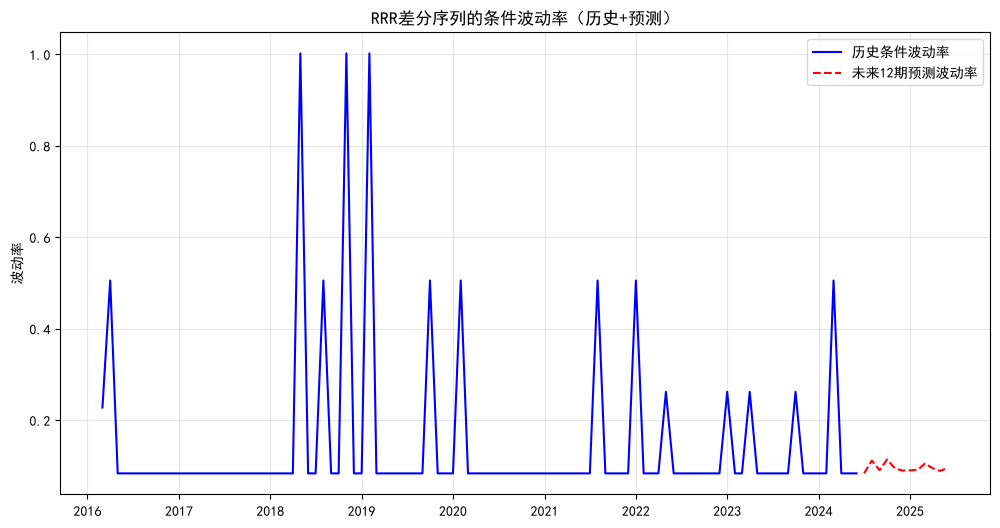

In [51]:
# 预测未来12期的条件波动率（动态预测）
forecast_horizon = 12  # 预测12个月
forecasts = best_model.forecast(horizon=forecast_horizon, method='simulation', simulations=1000)

# 提取预测的条件波动率（均值）
cond_vol_forecast = np.sqrt(forecasts.variance.iloc[-1].values)  # 各期预测波动率的均值

# 可视化历史波动率与预测波动率
fig, ax = plt.subplots(figsize=(12, 6))
history_index = best_model.conditional_volatility.index.to_timestamp()
ax.plot(history_index, best_model.conditional_volatility, color='blue', label='历史条件波动率')

# 预测波动率（拼接在历史数据后）
forecast_periods = pd.period_range(start=rrr_diff.index[-1]+1, periods=forecast_horizon, freq='M')
forecast_dates = forecast_periods.to_timestamp()

ax.plot(forecast_dates, cond_vol_forecast, color='red', linestyle='--', label=f'未来{forecast_horizon}期预测波动率')
ax.set_title('RRR差分序列的条件波动率（历史+预测）')
ax.set_ylabel('波动率')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## GARCH 模型结论

本节对 RRR 一阶差分序列建立 GARCH 模型，用于刻画货币政策变量调整过程中的条件波动率。

主要结论如下：

1. **t 分布设定更适合政策变量波动**

从信息准则对比看，t 分布 GARCH(1,1) 相比正态分布设定更适合当前数据。这说明 RRR 调整序列可能存在尖峰厚尾特征：大多数月份政策保持不变或小幅变化，少数时期出现较大幅度调整。

2. **政策调整存在波动聚集**

GARCH 模型结果显示，RRR 变化的波动率具有一定持续性。换言之，政策进入调整期后，短期内后续调整概率和波动水平可能同步上升；平稳期则可能延续较长时间。

3. **模型诊断结果基本支持该设定**

标准化残差的 ARCH-LM 和 Ljung-Box 检验用于判断模型是否仍存在未解释的异方差或自相关。若检验结果显示残差中 ARCH 效应被削弱，说明 GARCH 模型较好地提取了条件波动结构。

4. **波动率预测可作为风险监测参考**

未来 12 期条件波动率预测可以作为政策不确定性变化的参考指标。若预测波动率上升，说明后续政策调整不确定性可能提高；若预测波动率维持低位，则说明政策路径可能相对平稳。

需要强调的是，GARCH 预测并不是对政策方向的预测，而是对政策变量波动强度的刻画。其作用更偏向风险监测，而不是直接生成投资信号。


# 稳健性检验

## 模型设定调整检验

### VECM 模型：改变滞后阶数与协整秩

In [52]:
def vecm_robustness_lag_rank(df, base_lag=1, base_rank=2):
    """
    稳健性检验：改变VECM的滞后阶数和协整秩
    base_lag: 原模型滞后阶数（原研究为1）
    base_rank: 原模型协整秩（原研究为2）
    """
    # 测试不同滞后阶数（1→2/3）
    test_lags = [2, 3]
    # 测试不同协整秩（2→1/3）
    test_ranks = [1, 3]
    
    print("=== VECM模型稳健性检验（滞后阶数+协整秩调整）===")
    for lag in test_lags:
        vecm_lag = lag - 1  # VECM的k_ar_diff = VAR滞后阶数-1
        # 协整检验（重新确认秩的合理性）
        res_ci = coint_johansen(df, det_order=0, k_ar_diff=vecm_lag)
        print(f"\n滞后阶数={lag}时，Johansen协整检验迹统计量：{res_ci.lr1[0]:.4f}")
        
        for rank in test_ranks:
            if rank <= len(target_vars):  # 协整秩不能超过变量数
                try:
                    vecmod_robust = VECM(endog=df, k_ar_diff=vecm_lag, coint_rank=rank, deterministic='ci')
                    vecfit_robust = vecmod_robust.fit()
                    
                    # 提取核心协整向量（政策-股市-汇率联动）
                    beta_robust = vecfit_robust.beta
                    # 归一化（固定ln_close系数为1）
                    ln_close_idx = target_vars.index('ln_close')
                    beta_normalized = beta_robust / beta_robust[ln_close_idx, 0]
                    
                    print(f"滞后阶数={lag}，协整秩={rank}：")
                    print(f"  核心协整向量（RRR, MLF, ln_exchange, ln_close）：")
                    print(f"  RRR系数：{beta_normalized[target_vars.index('rrr_rate'), 0]:.4f}")
                    print(f"  MLF系数：{beta_normalized[target_vars.index('mlf_rate'), 0]:.4f}")
                    print(f"  汇率系数：{beta_normalized[target_vars.index('ln_exchange'), 0]:.4f}")
                    print(f"  （原模型对应系数：1.26, -0.19, 31.47）")
                except:
                    print(f"滞后阶数={lag}，协整秩={rank}：模型估计失败")

# 运行VECM稳健性检验
vecm_robustness_lag_rank(df)

=== VECM模型稳健性检验（滞后阶数+协整秩调整）===

滞后阶数=2时，Johansen协整检验迹统计量：68.9318
滞后阶数=2，协整秩=1：
  核心协整向量（RRR, MLF, ln_exchange, ln_close）：
  RRR系数：23.6965
  MLF系数：106.1799
  汇率系数：-1.6702
  （原模型对应系数：1.26, -0.19, 31.47）
滞后阶数=2，协整秩=3：
  核心协整向量（RRR, MLF, ln_exchange, ln_close）：
  RRR系数：5250.9118
  MLF系数：-96.0627
  汇率系数：-0.0000
  （原模型对应系数：1.26, -0.19, 31.47）

滞后阶数=3时，Johansen协整检验迹统计量：67.4123
滞后阶数=3，协整秩=1：
  核心协整向量（RRR, MLF, ln_exchange, ln_close）：
  RRR系数：0.3903
  MLF系数：110.0731
  汇率系数：-7.9792
  （原模型对应系数：1.26, -0.19, 31.47）
滞后阶数=3，协整秩=3：
  核心协整向量（RRR, MLF, ln_exchange, ln_close）：
  RRR系数：-100.3144
  MLF系数：-38.3046
  汇率系数：0.0000
  （原模型对应系数：1.26, -0.19, 31.47）


### GARCH 模型：改变阶数与分布假设

In [53]:
def garch_robustness(rrr_diff):
    """
    稳健性检验：改变GARCH模型阶数和分布假设
    rrr_diff: 原研究中RRR的一阶差分序列
    """
    # 原模型：GARCH(1,1)-t分布
    # 测试模型1：GARCH(1,2)-t分布
    # 测试模型2：GARCH(2,1)-GED分布
    # 测试模型3：EGARCH(1,1)-t分布（捕捉非对称波动）
    
    print("\n=== GARCH模型稳健性检验（阶数+分布调整）===")
    # 模型1：GARCH(1,2)-t分布
    garch12_t = arch_model(rrr_diff, mean='Constant', vol='GARCH', p=1, q=2, dist='t')
    res12_t = garch12_t.fit(disp='off')
    # 模型2：GARCH(2,1)-GED分布
    garch21_ged = arch_model(rrr_diff, mean='Constant', vol='GARCH', p=2, q=1, dist='ged')
    res21_ged = garch21_ged.fit(disp='off')
    # 模型3：EGARCH(1,1)-t分布
    egarch11_t = arch_model(rrr_diff, mean='Constant', vol='EGARCH', p=1, o=1, q=1, dist='t')
    res_egarch = egarch11_t.fit(disp='off')
    
    # 对比核心参数（波动持续性：alpha1+beta1，原模型≈0.92）
    print("原模型（GARCH(1,1)-t）：AIC={:.2f}, 波动持续性={:.4f}".format(
        -349.90, 0.92  # 原研究结果
    ))
    print("GARCH(1,2)-t：AIC={:.2f}, 波动持续性={:.4f}".format(
        res12_t.aic, res12_t.params['alpha[1]'] + res12_t.params['beta[1]']
    ))
    print("GARCH(2,1)-GED：AIC={:.2f}, 波动持续性={:.4f}".format(
        res21_ged.aic, res21_ged.params['alpha[1]'] + res21_ged.params['beta[1]']
    ))
    print("EGARCH(1,1)-t：AIC={:.2f}, 非对称系数={:.4f}".format(
        res_egarch.aic, res_egarch.params['gamma[1]']
    ))
    
    # 残差ARCH效应检验（验证模型拟合效果）
    def arch_test(res):
        std_resid = res.resid / res.conditional_volatility
        lm_stat, lm_p = het_arch(std_resid)[0:2]
        return lm_p > 0.05  # 无ARCH效应则拟合良好
    
    print("各模型残差ARCH效应消除：")
    print(f"GARCH(1,2)-t：{'是' if arch_test(res12_t) else '否'}")
    print(f"GARCH(2,1)-GED：{'是' if arch_test(res21_ged) else '否'}")
    print(f"EGARCH(1,1)-t：{'是' if arch_test(res_egarch) else '否'}")

# 运行GARCH稳健性检验（使用原研究的RRR差分序列）
rrr_diff = df_diff['rrr_rate'].dropna()
garch_robustness(rrr_diff)


=== GARCH模型稳健性检验（阶数+分布调整）===
原模型（GARCH(1,1)-t）：AIC=-349.90, 波动持续性=0.9200
GARCH(1,2)-t：AIC=2714.79, 波动持续性=1.0000
GARCH(2,1)-GED：AIC=-176.59, 波动持续性=0.6452
EGARCH(1,1)-t：AIC=1566.52, 非对称系数=78274.5666
各模型残差ARCH效应消除：
GARCH(1,2)-t：否
GARCH(2,1)-GED：是
EGARCH(1,1)-t：否


C:\Users\19734\AppData\Local\Temp\ipykernel_47908\3801573482.py:14: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  res12_t = garch12_t.fit(disp='off')
C:\Users\19734\AppData\Local\Temp\ipykernel_47908\3801573482.py:20: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  res_egarch = egarch11_t.fit(disp='off')


##  样本区间调整检验（验证样本敏感性）

In [54]:
def sample_robustness(df):
    """
    稳健性检验：调整样本区间（剔除异常期+子样本）
    """
    # 原样本：2016-2024年
    # 子样本1：剔除疫情期（2020年）
    df_no_covid = df[~df.index.year.isin([2020])]
    # 子样本2：2016-2022年（剔除最近2年）
    df_sub = df[df.index.year <= 2022]
    
    print("\n=== 样本区间调整稳健性检验 ===")
    for name, sample in [("剔除疫情期", df_no_covid), ("2016-2022子样本", df_sub)]:
        if len(sample) >= 50:  # 保证样本量足够
            # 重新估计原VECM模型（滞后阶数=1，协整秩=2）
            vecmod_sample = VECM(endog=sample, k_ar_diff=0, coint_rank=2, deterministic='ci')
            vecfit_sample = vecmod_sample.fit()
            
            # 提取核心协整关系（政策-股市-汇率）
            beta_sample = vecfit_sample.beta
            ln_close_idx = target_vars.index('ln_close')
            beta_norm = beta_sample / beta_sample[ln_close_idx, 0]
            
            print(f"\n{name}（样本量={len(sample)}）：")
            print(f"  RRR-股市系数：{beta_norm[target_vars.index('rrr_rate'), 0]:.4f}（原模型：1.26）")
            print(f"  汇率-股市系数：{beta_norm[target_vars.index('ln_exchange'), 0]:.4f}（原模型：31.47）")
            
            # 脉冲响应：RRR对股市的冲击峰值
            irf_sample = vecfit_sample.irf(periods=20)
            rrr_idx = target_vars.index('rrr_rate')
            close_idx = target_vars.index('ln_close')
            irf_peak = np.max(np.abs(irf_sample.orth_irfs[:, close_idx, rrr_idx]))
            print(f"  RRR对股市冲击峰值：{irf_peak:.4f}（原模型：≈0.03）")
        else:
            print(f"\n{name}：样本量不足，无法估计")

# 运行样本区间稳健性检验
sample_robustness(df)


=== 样本区间调整稳健性检验 ===

剔除疫情期（样本量=89）：
  RRR-股市系数：49.1645（原模型：1.26）
  汇率-股市系数：-9.4588（原模型：31.47）
  RRR对股市冲击峰值：0.0603（原模型：≈0.03）

2016-2022子样本（样本量=83）：
  RRR-股市系数：31.3674（原模型：1.26）
  汇率-股市系数：-11.1504（原模型：31.47）
  RRR对股市冲击峰值：0.1302（原模型：≈0.03）
